<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/RandomForest_Scratch_NLP_ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: LOAD IMDB DATASET & CREATE TF‑IDF FEATURES
# ============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re

# ---------- Load IMDB Dataset ----------
print("📀 Loading IMDB Dataset...")
imdb = pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='warn')
imdb = imdb[['review', 'sentiment']]
imdb['label'] = imdb['sentiment'].map({'positive': 1, 'negative': 0})

# ---------- Simple Text Cleaning ----------
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)      # Remove HTML breaks
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # Keep only letters
    text = text.lower().strip()
    return text

imdb['clean_review'] = imdb['review'].apply(clean_text)

# ---------- TF‑IDF Vectorization ----------
# Use a small vocabulary to keep tree training feasible
MAX_FEATURES = 5000
vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, stop_words='english')
X = vectorizer.fit_transform(imdb['clean_review']).toarray()
y = imdb['label'].values

print(f"✅ Feature matrix shape: {X.shape}")

# ---------- Train/Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

📀 Loading IMDB Dataset...


/tmp/ipykernel_16758/3392826348.py:13: ParserWarning: Skipping line 4763: unexpected end of data

  imdb = pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='warn')


✅ Feature matrix shape: (4761, 5000)
Training samples: 3808, Test samples: 953


In [ ]:
# ============================================================
# CELL 2: DECISION TREE & RANDOM FOREST FROM SCRATCH
# ============================================================

import numpy as np
from collections import Counter

# -------------------- Decision Tree Node --------------------
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature          # which feature to split on
        self.threshold = threshold      # threshold value for split
        self.left = left                # left child (<= threshold)
        self.right = right              # right child (> threshold)
        self.value = value              # class label if leaf node

# -------------------- Decision Tree Classifier --------------------
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=5, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features  # number of features to consider for each split
        self.root = None

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        # If max_features not set, use all features
        self.max_features_ = X.shape[1] if self.max_features is None else min(self.max_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Randomly select subset of features to consider
        feat_idxs = np.random.choice(n_features, self.max_features_, replace=False)

        # Find best split among selected features
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feat is None:  # no split improves impurity
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Split data and grow children
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_feat, split_thresh = None, None
        current_entropy = self._entropy(y)

        for feat in feat_idxs:
            X_column = X[:, feat]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                # Binary split
                left_mask = X_column <= thr
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Information gain
                left_entropy = self._entropy(y[left_mask])
                right_entropy = self._entropy(y[right_mask])
                n = len(y)
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                child_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy
                info_gain = current_entropy - child_entropy

                if info_gain > best_gain:
                    best_gain = info_gain
                    split_feat = feat
                    split_thresh = thr

        return split_feat, split_thresh

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


# -------------------- Random Forest Classifier --------------------
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=5, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape

        # Determine max_features per tree
        if self.max_features == 'sqrt':
            self.max_features_ = int(np.sqrt(n_features))
        elif isinstance(self.max_features, int):
            self.max_features_ = self.max_features
        else:
            self.max_features_ = n_features

        for i in range(self.n_trees):
            print(f"  Training tree {i+1}/{self.n_trees}...", end='\r')
            # Bootstrap sampling
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X[idxs], y[idxs]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features_
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        print("\n✅ Random Forest training complete!")

    def predict(self, X):
        # Collect predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        majority = []
        for i in range(X.shape[0]):
            votes = tree_preds[:, i]
            majority.append(Counter(votes).most_common(1)[0][0])
        return np.array(majority)

    def predict_proba(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Fraction of trees voting for class 1
        proba = np.mean(tree_preds == 1, axis=0)
        return np.column_stack([1 - proba, proba])

🌲 Training Random Forest (from scratch)...

✅ Random Forest training complete!

📊 Test Accuracy: 0.7156 (71.56%)

📋 Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.57      0.67       470
    Positive       0.67      0.85      0.75       483

    accuracy                           0.72       953
   macro avg       0.73      0.71      0.71       953
weighted avg       0.73      0.72      0.71       953



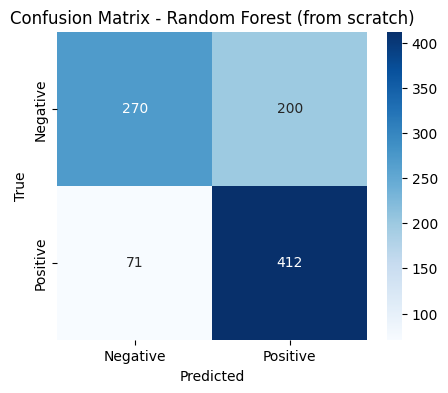

In [ ]:
# ============================================================
# CELL 3: TRAIN RANDOM FOREST & SHOW ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Train Random Forest ----------
print("🌲 Training Random Forest (from scratch)...")
rf = RandomForest(
    n_trees=10,                # small number for demo (increase for better accuracy)
    max_depth=15,
    min_samples_split=10,
    max_features='sqrt'        # random subset of features per split
)
rf.fit(X_train, y_train)

# ---------- Predictions ----------
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

# ---------- Accuracy ----------
acc = accuracy_score(y_test, y_pred)
print(f"\n📊 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ---------- Detailed Report ----------
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Random Forest (from scratch)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()